## **Análise Exploratória**

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import altair as alt

In [5]:
# Carregando o dataset (coração)
df = pd.read_csv("/content/heart.csv")

# Ver
df.head(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


As colunas existentes no dataset escolhido são:

1. **Idade**

2. **Sexo**

3. **Tipo_de_dor_no_peito (4 valores possíveis)**

4. **Pressao_arterial_em_repouso**

5. **Colesterol_serico_mg_dl**

6. **Glicemia_de_jejum_maior_120mg_dl**

7. **Eletrocardiograma_repouso (valores: 0, 1, 2)**

8. **Frequencia_cardiaca_maxima**

9. **Angina_induzida_por_exercicio**

10. **Oldpeak (depressão do segmento ST induzida pelo exercício em relação ao repouso)**

11. **Inclinacao_ST_pico_exercicio**

12. **Numero_grandes_vasos_fluorescencia (valores: 0–3)**

13. **Escala_defeito (0 = normal; 1 = defeito fixo; 2 = defeito reversível)**


In [6]:
# Informações
df.info()

# Verificar valores nulos
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


Na tabela acima, podemos verificar que não há dados faltantes no Dataset.

## Analisando somente a coluna da Idade:

In [7]:
df["age"].describe()


,age
count,1025.000000
mean,54.434146
std,9.072290
min,29.000000
25%,48.000000
50%,56.000000
75%,61.000000
max,77.000000


Verificamos a idade min é de 29 e a máx é 77 anos, ou seja, não temos valores potenciais valores estranhos também.

In [8]:
df["sex"] = df["sex"].map({0: "Mulher", 1: "Homem"})


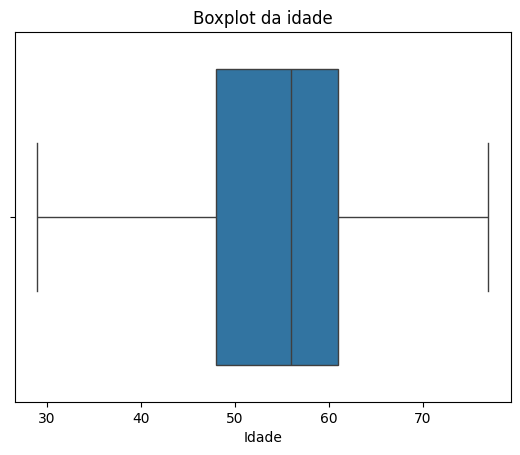

In [9]:
# Outliers
sns.boxplot(x=df["age"])
plt.xlabel("Idade")
plt.title("Boxplot da idade")
plt.show()


Com o boxplot, podemos verificar que não temos outliers nos dados.

### Análise da distribuição da coluna idade (em anos)

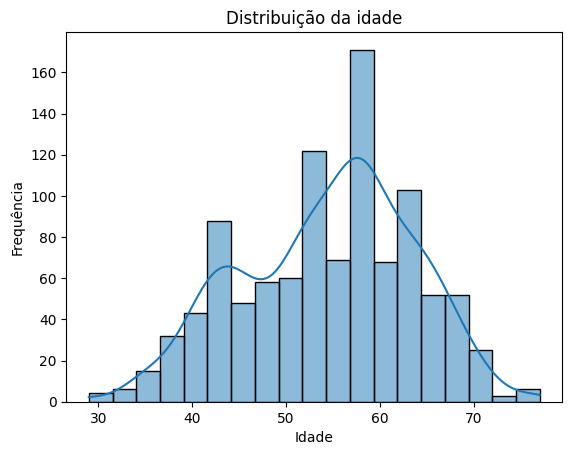

In [10]:
#Distribuição de idade
sns.histplot(df["age"],kde=True)
plt.xlabel("Idade")
plt.ylabel("Frequência")
plt.title("Distribuição da idade")
plt.show()


In [11]:
#Grafico da quantidade de homens e mulheres
alt.Chart(df).mark_bar().encode(
    x=alt.X('sex:O', title='Sexo'),
    y=alt.Y('count():Q', title='Quantidade'),
).properties(
    title='Quantidade por Sexo',
    width=300, #largura
    height=600 #altura
)

alt.Chart(...)

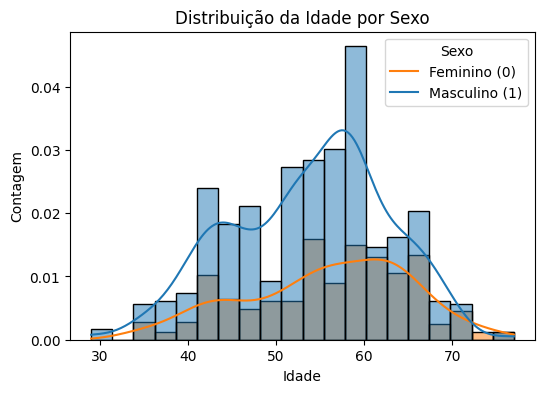

Estatística t: -3.250405780831748
p-valor: 0.001220952641228987
Há diferença significativa na idade média entre homens e mulheres.


In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
# Distribuição das idades por sexo
plt.figure(figsize=(6,4))
sns.histplot(data=df, x="age", hue="sex", kde=True, bins=20, alpha=0.5,stat="density" )
plt.title("Distribuição da Idade por Sexo")
plt.xlabel("Idade")
plt.ylabel("Contagem")
plt.legend(title="Sexo", labels=["Feminino (0)", "Masculino (1)"])
plt.show()

# Teste t
from scipy.stats import ttest_ind

idade_homens = df[df["sex"] == "Homem"]["age"]
idade_mulheres = df[df["sex"] == "Mulher"]["age"]

t_stat, p_value = ttest_ind(idade_homens, idade_mulheres, equal_var=False)

print("Estatística t:", t_stat)
print("p-valor:", p_value)

if p_value < 0.05:
    print("Há diferença significativa na idade média entre homens e mulheres.")
else:
    print("Não há diferença significativa na idade média entre homens e mulheres.")

In [13]:
df.groupby("sex")["age"].describe()


,count,mean,std,min,25%,50%,75%,max
sex,,,,,,,,
Homem,713.0,53.814867,8.875668,29.0,47.0,55.0,60.0,77.0
Mulher,312.0,55.849359,9.368127,34.0,50.0,57.0,63.0,76.0


Análise: Há uma indicação de que as mulheres do estudo são, em geral, mais velhas. Como a idade é **fator de risco** para problemas cardíacos, isso pode influenciar os resultados clínicos (ex: pressão alta, angina, defeitos eletrocardiográficos) das mulheres.

In [14]:
import pandas as pd

# Ajuste os bins conforme o range das idades do seu dataset
bins = [29, 40, 50, 60, 70, 80]
labels = ['30-40', '41-50', '51-60', '61-70', '71-80']

df['Faixa_Idade'] = pd.cut(df['age'], bins=bins, labels=labels, right=True)


In [15]:
tabela = df.groupby(['Faixa_Idade', 'sex', 'cp']).size().unstack(fill_value=0)
print(tabela)


cp                    0   1   2   3
Faixa_Idade sex                    
30-40       Homem    19   4  14  10
            Mulher    4   3  10   0
41-50       Homem    76  40  57   6
            Mulher   19  25  24   0
51-60       Homem   175  49  74  27
            Mulher   50  20  36   7
61-70       Homem    91  13  30  21
            Mulher   56   3  32   6
71-80       Homem     3   0   0   0
            Mulher    4   6   7   0


/tmp/ipython-input-436473530.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tabela = df.groupby(['Faixa_Idade', 'sex', 'cp']).size().unstack(fill_value=0)


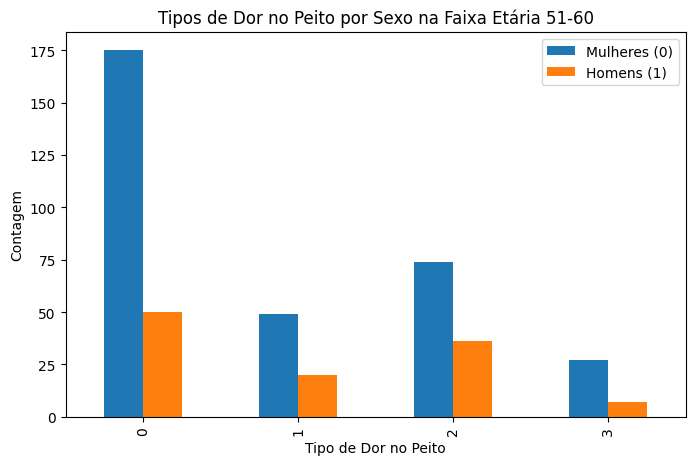

In [16]:
import matplotlib.pyplot as plt

faixa = '51-60'
dados_faixa = df[df['Faixa_Idade'] == faixa]

# Contar tipos de dor no peito por sexo
contagem = dados_faixa.groupby(['cp', 'sex']).size().unstack()

contagem.plot(kind='bar', figsize=(8,5))
plt.title(f'Tipos de Dor no Peito por Sexo na Faixa Etária {faixa}')
plt.xlabel('Tipo de Dor no Peito')
plt.ylabel('Contagem')
plt.legend(['Mulheres (0)', 'Homens (1)'])
plt.show()


Contagem absoluta:
sex  Homem  Mulher
cp                
0      175      50
1       49      20
2       74      36
3       27       7

Proporções (% dentro do sexo):
sex  Homem  Mulher
cp                
0     53.8    44.2
1     15.1    17.7
2     22.8    31.9
3      8.3     6.2


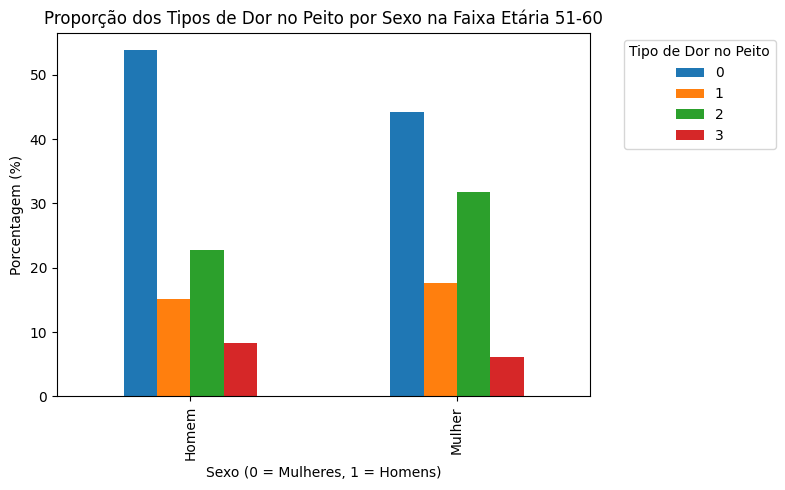

In [17]:
import pandas as pd
import matplotlib.pyplot as plt


faixa = '51-60'
df_faixa = df[df['Faixa_Idade'] == faixa]

# Conta o total por sexo para calcular as proporções
total_por_sexo = df_faixa.groupby('sex').size()

# Conta quantos para cada tipo de dor no peito por sexo
contagem = df_faixa.groupby(['cp', 'sex']).size().unstack(fill_value=0)

# Calcula a proporção dentro de cada sexo
proporcoes = contagem.div(total_por_sexo, axis=1) * 100  # em porcentagem

print("Contagem absoluta:")
print(contagem)
print("\nProporções (% dentro do sexo):")
print(proporcoes.round(1))


proporcoes.T.plot(kind='bar', figsize=(8,5))
plt.title(f'Proporção dos Tipos de Dor no Peito por Sexo na Faixa Etária {faixa}')
plt.xlabel('Sexo (0 = Mulheres, 1 = Homens)')
plt.ylabel('Porcentagem (%)')
plt.legend(title='Tipo de Dor no Peito', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [18]:
df[['age','trestbps','chol','thalach','oldpeak']].describe()


,age,trestbps,chol,thalach,oldpeak
count,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000
mean,54.434146,131.611707,246.00000,149.114146,1.071512
std,9.072290,17.516718,51.59251,23.005724,1.175053
min,29.000000,94.000000,126.00000,71.000000,0.000000
25%,48.000000,120.000000,211.00000,132.000000,0.000000
50%,56.000000,130.000000,240.00000,152.000000,0.800000
75%,61.000000,140.000000,275.00000,166.000000,1.800000
max,77.000000,200.000000,564.00000,202.000000,6.200000


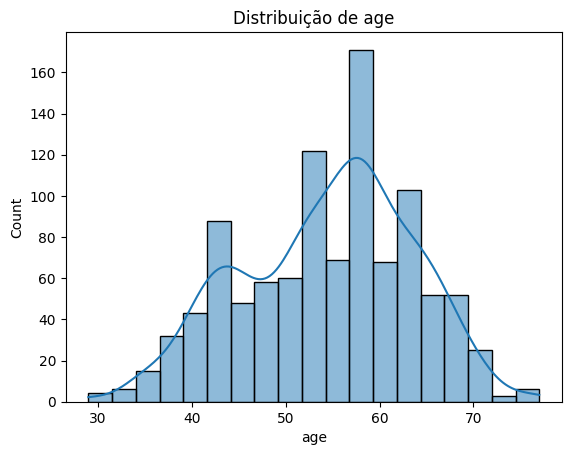

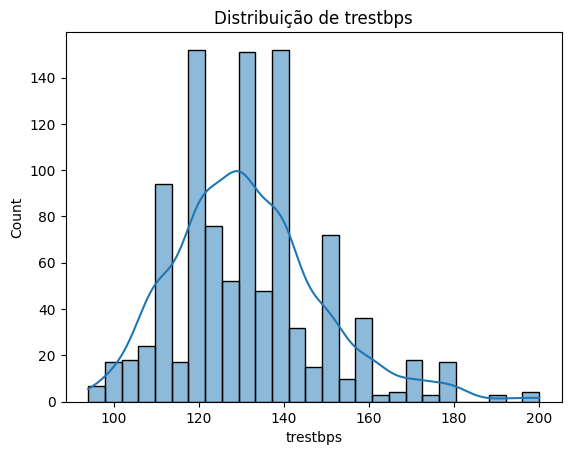

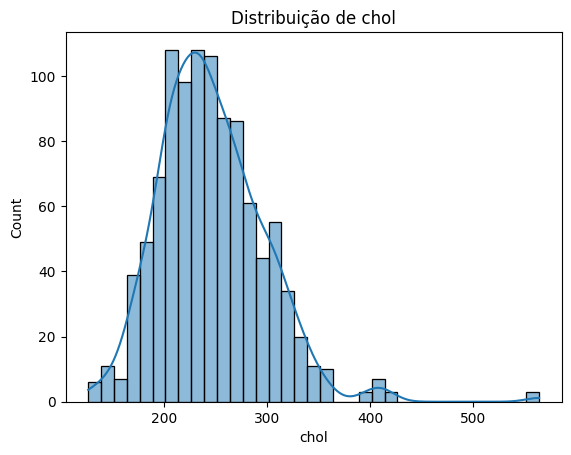

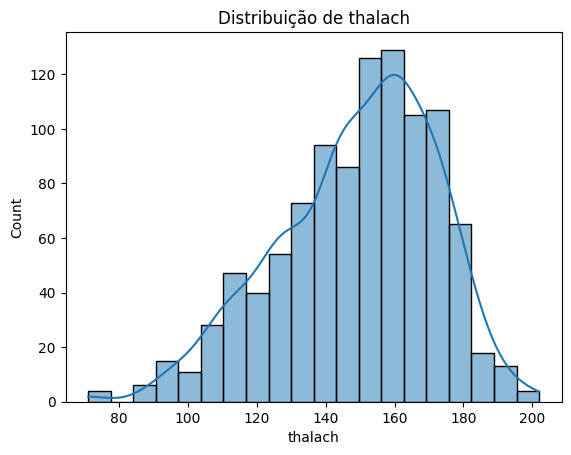

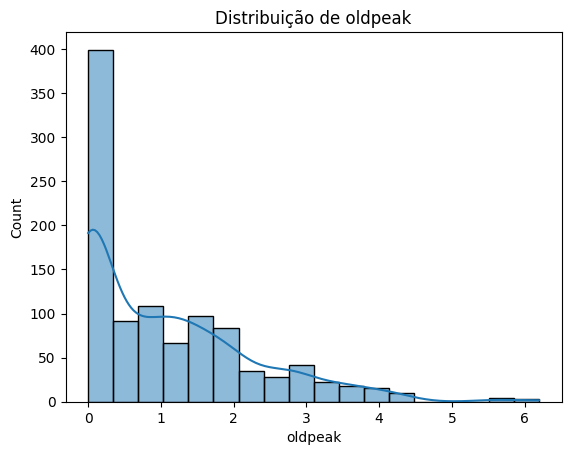

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in ['age','trestbps','chol','thalach','oldpeak']:
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribuição de {col}')
    plt.show()


In [20]:
df['sex'].value_counts(normalize=True) * 100
df['cp'].value_counts()


,count
cp,
0,497
2,284
1,167
3,77


In [21]:
import altair as alt

alt.Chart(df).mark_bar().encode(
    x=alt.X('count()', title='Contagem'),
    y=alt.Y('cp:O', title='Tipo de dor no peito'),
    color='cp:N'
).properties(title='Distribuição de tipo de dor no peito')


alt.Chart(...)